<a href="https://colab.research.google.com/github/GuruShrihari/Credit_Card_Fraud/blob/main/Credit_Card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, precision_recall_curve
from imblearn.pipeline import Pipeline

In [13]:
d = pd.read_csv("creditcard.csv")

print("Max nulls in any column:", d.isnull().sum().max())

df = d.copy()

#Extremely imbalanced , not efficient to over/undersample

print(df["Class"].value_counts())

Max nulls in any column: 0
Class
0    284315
1       492
Name: count, dtype: int64


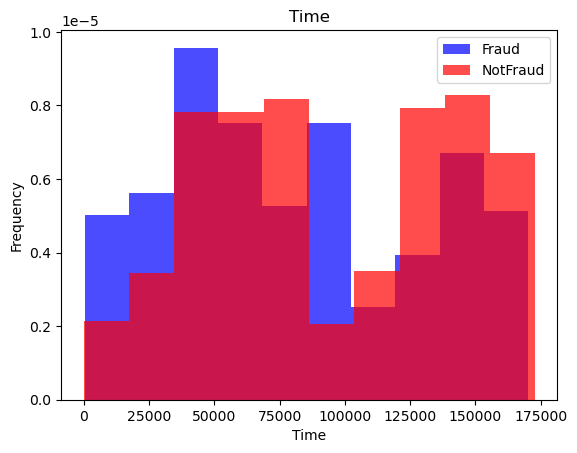

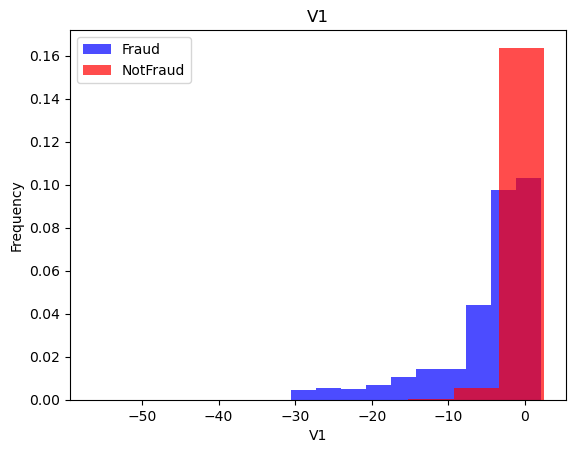

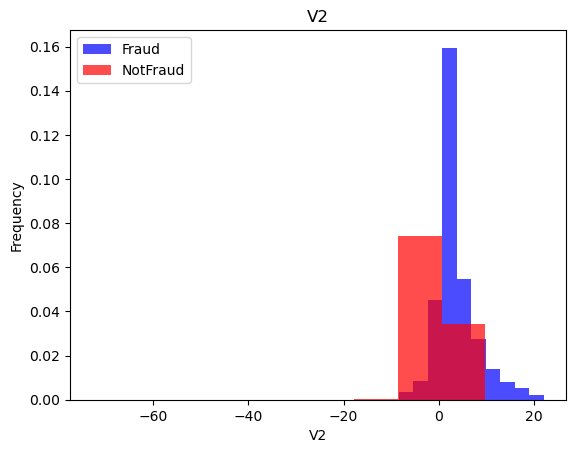

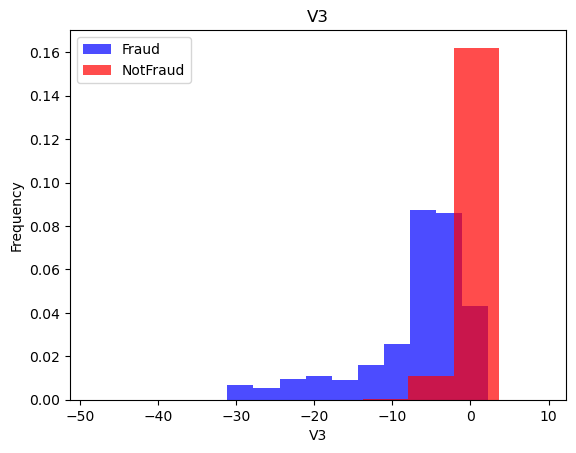

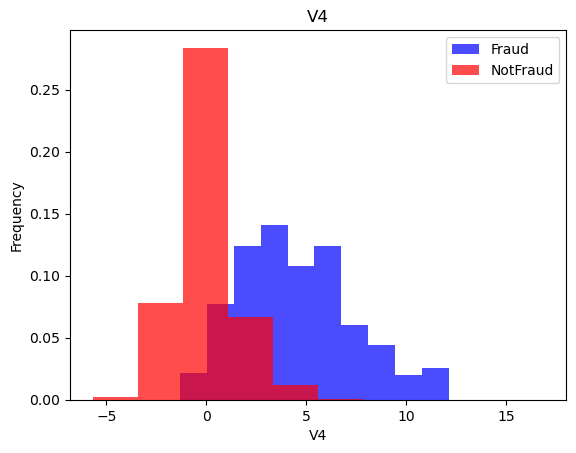

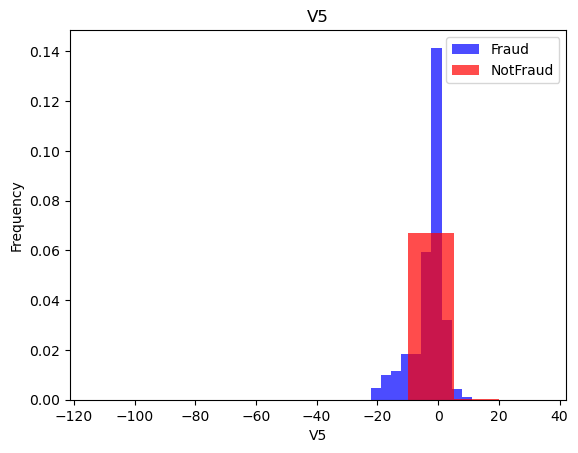

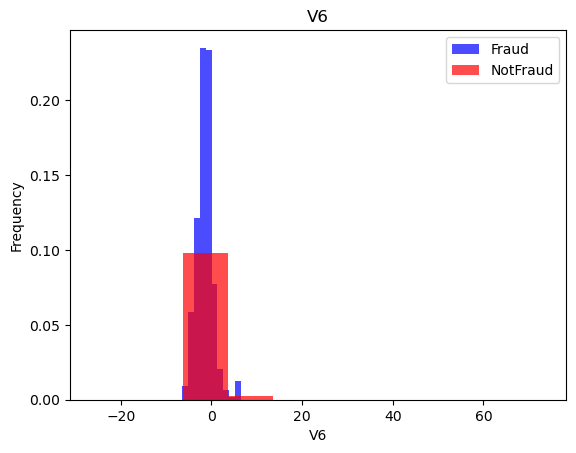

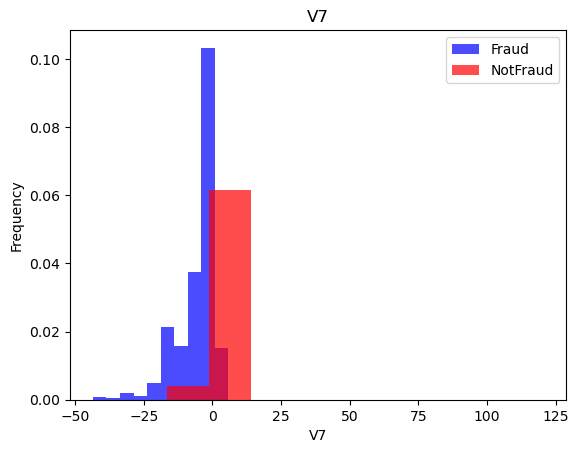

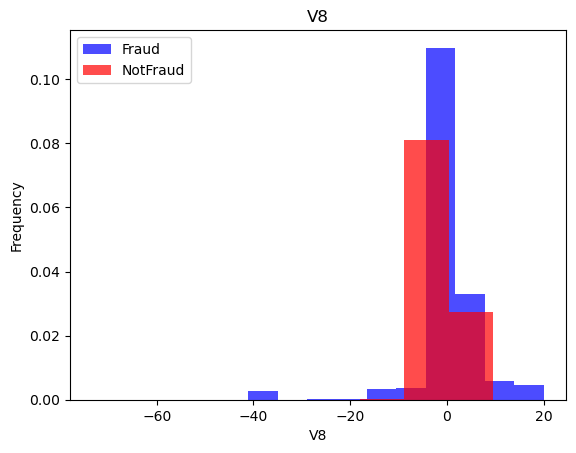

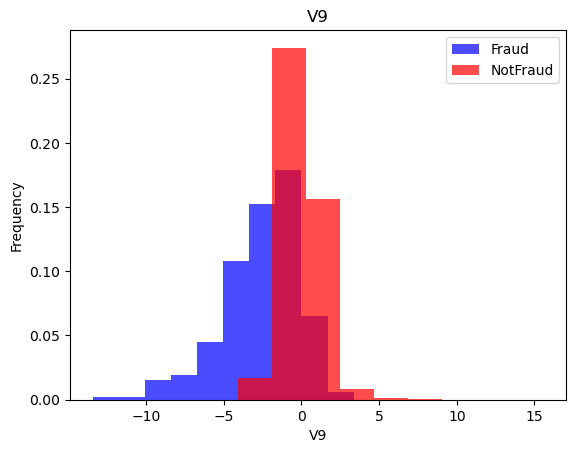

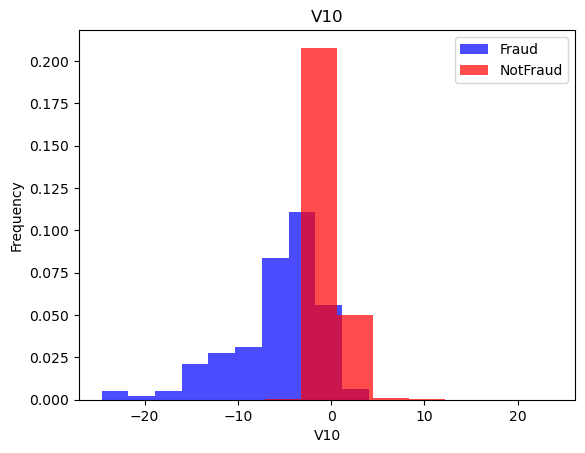

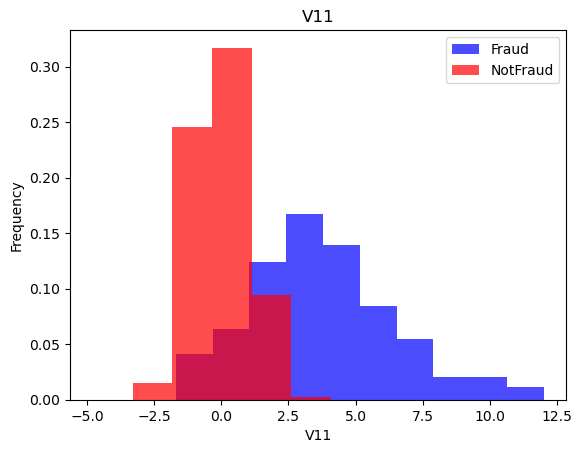

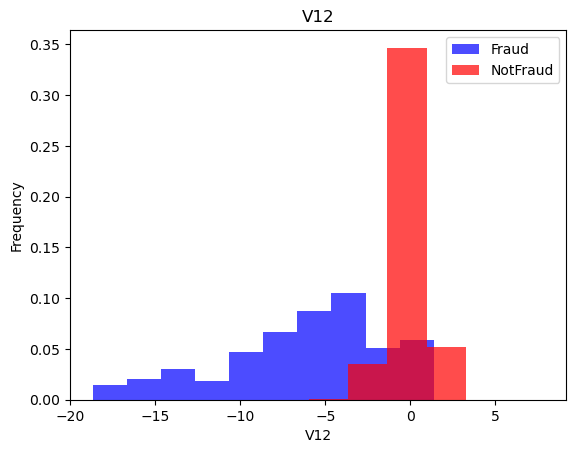

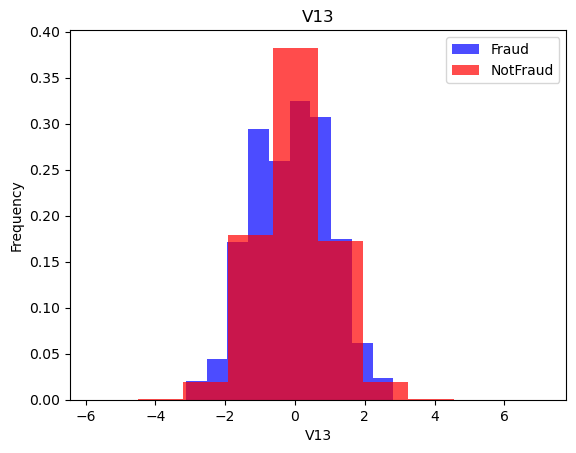

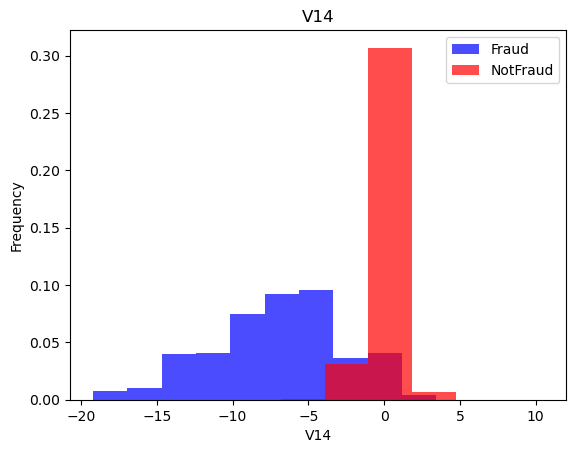

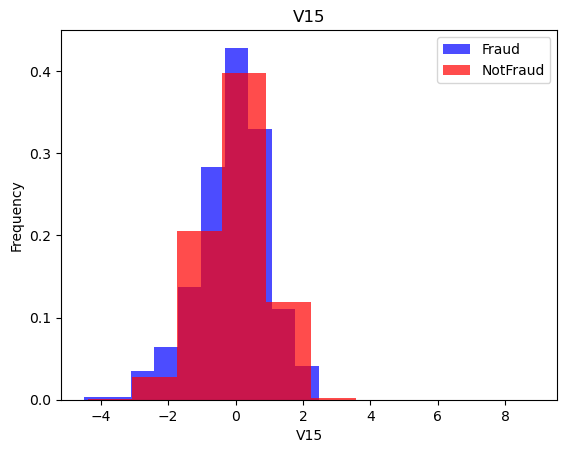

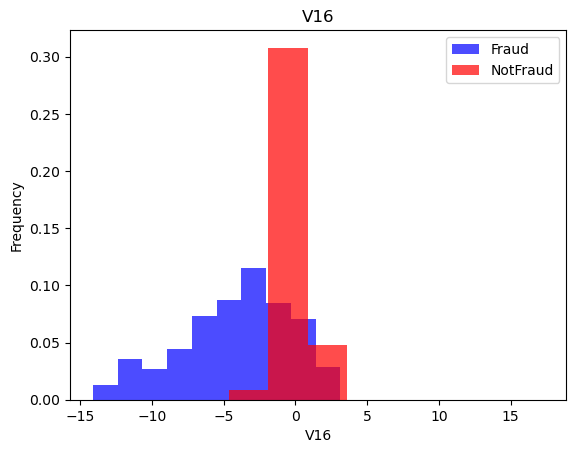

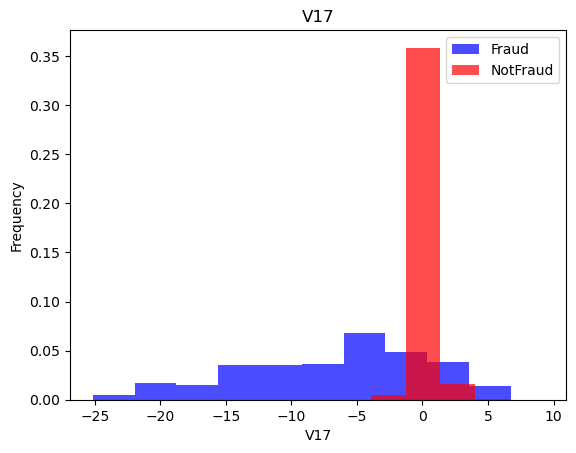

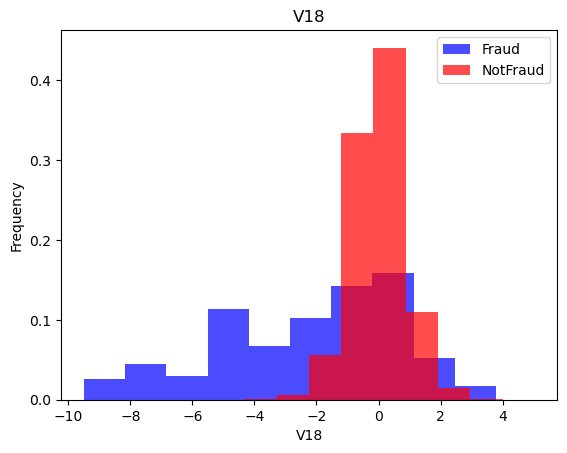

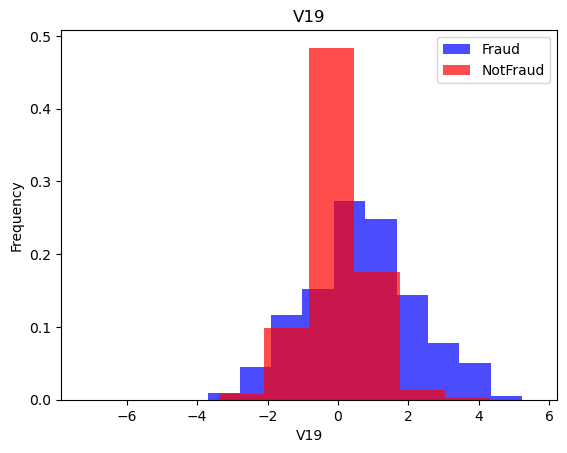

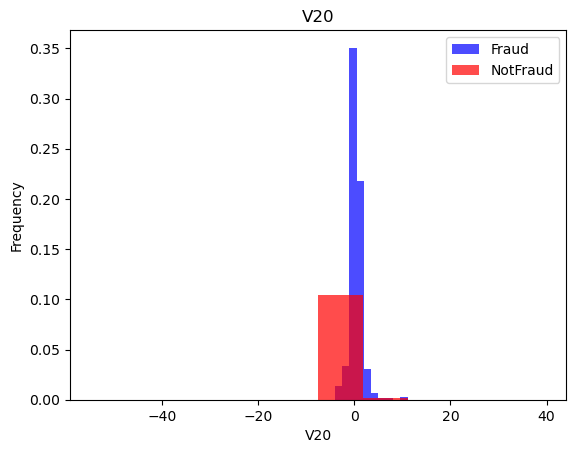

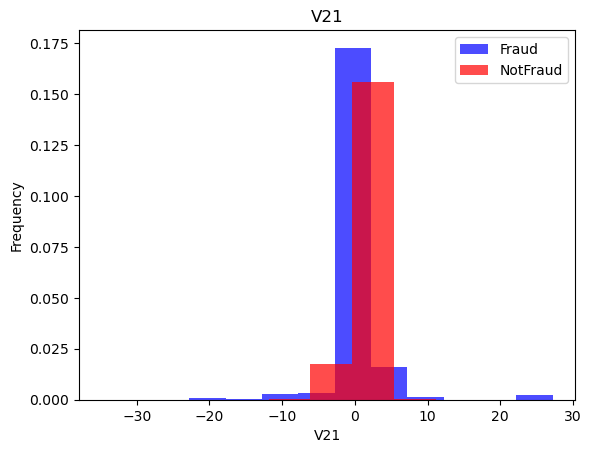

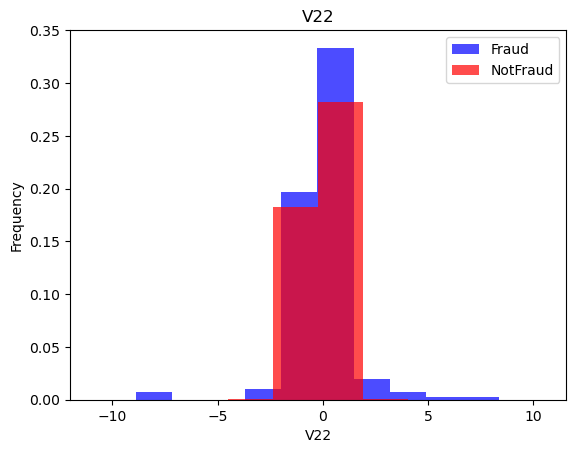

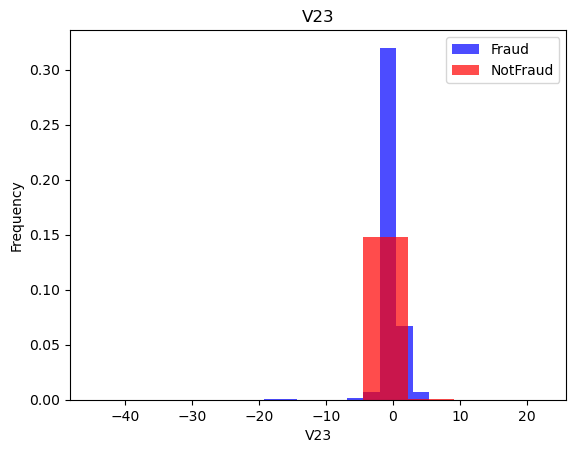

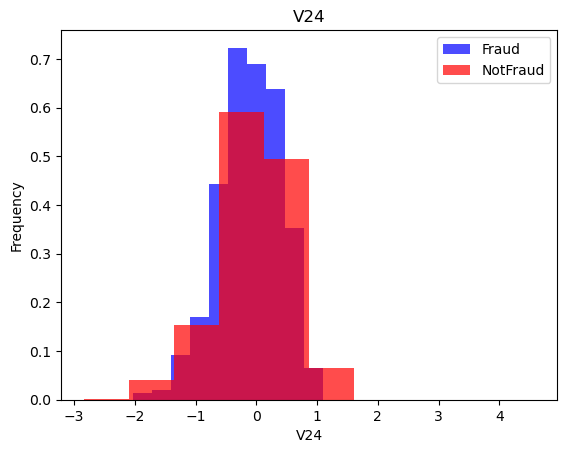

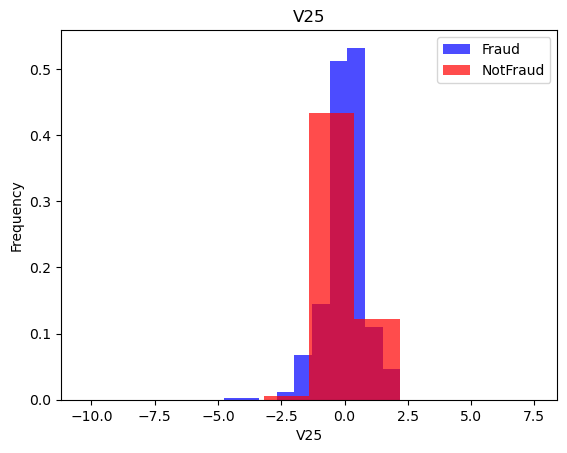

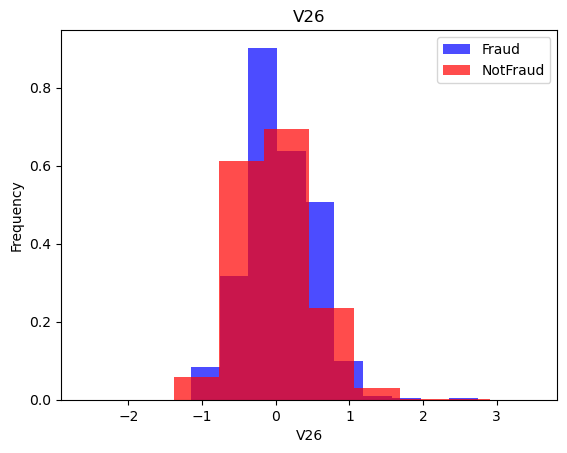

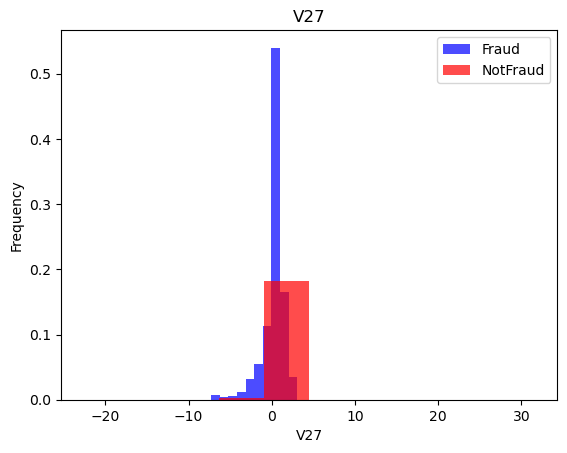

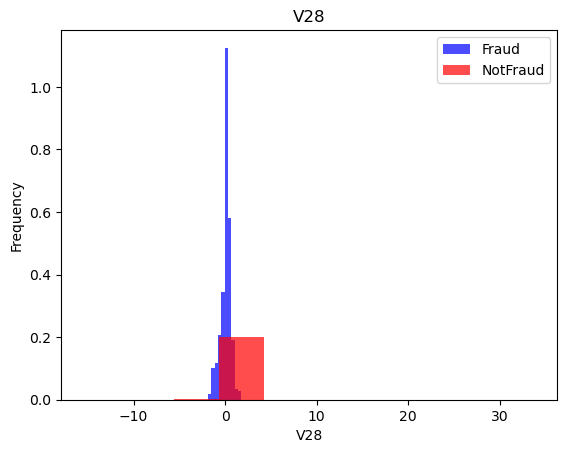

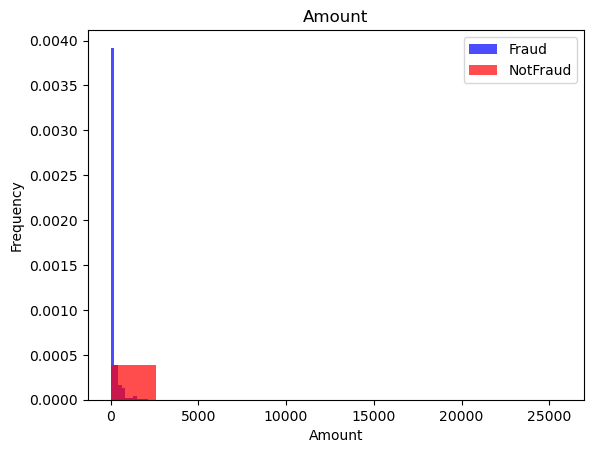

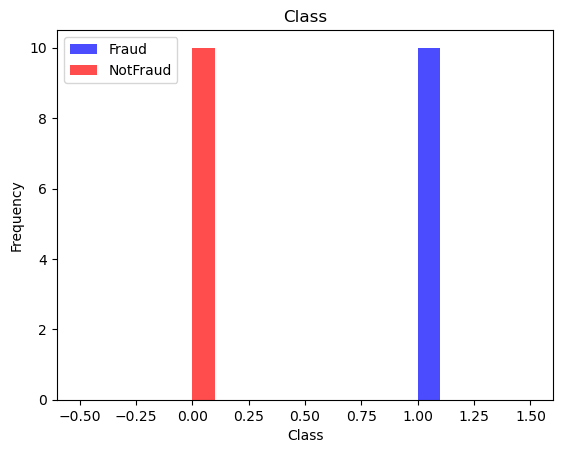

In [14]:
for labels in df.columns:
  plt.hist(df[df["Class"] == 1][labels],color="blue", label="Fraud",alpha= 0.7, density=True)
  plt.hist(df[df["Class"] == 0][labels],color="red", label="NotFraud",alpha= 0.7, density=True)
  plt.title(labels)
  plt.xlabel(labels)
  plt.ylabel("Frequency")
  plt.legend()
  plt.show()

# **Train, Test , Validation**

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,   #makes sure that train and test sets keep the same class proportions as the original data.
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)

In [16]:
print(y_train.value_counts())

Class
0    170588
1       295
Name: count, dtype: int64


# **Logistic Regression**

In [17]:
from sklearn.linear_model import LogisticRegression
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight={0:1, 1:50},
        solver="lbfgs"
    ))
])


In [18]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [19]:
y_valid_pred = pipeline.predict(X_valid)

y_valid_proba = pipeline.predict_proba(X_valid)[:, 1]

print("Validation Results:")
print(classification_report(y_valid, y_valid_pred))


Validation Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.40      0.82      0.54        99

    accuracy                           1.00     56962
   macro avg       0.70      0.91      0.77     56962
weighted avg       1.00      1.00      1.00     56962



In [20]:
print("Validation ROC-AUC:", roc_auc_score(y_valid, y_valid_proba))
print("Validation PR-AUC:", average_precision_score(y_valid, y_valid_proba))

Validation ROC-AUC: 0.9730639138514208
Validation PR-AUC: 0.6980354634047375


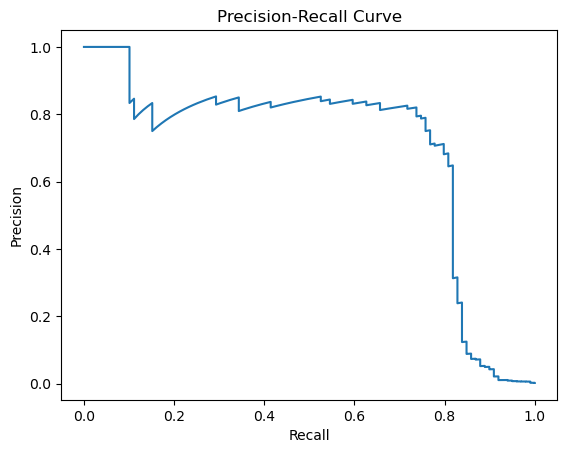

Validation Results at the threshold=0.1
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56863
           1       0.08      0.86      0.15        99

    accuracy                           0.98     56962
   macro avg       0.54      0.92      0.57     56962
weighted avg       1.00      0.98      0.99     56962



In [21]:
precision, recall, thresholds = precision_recall_curve(y_valid, y_valid_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

threshold = 0.1  # lower threshold => catchs more frauds (Threshold is set lower as the dataset is imbalanced)
y_valid_custom = (y_valid_proba >= threshold).astype(int)

print(f"Validation Results at the threshold={threshold}")
print(classification_report(y_valid, y_valid_custom))

In [22]:
y_test_proba = pipeline.predict_proba(X_test)[:, 1]


y_test_custom = (y_test_proba >= threshold).astype(int)

print("Test Results:")
print(classification_report(y_test, y_test_custom))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_test_proba))

Test Results:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.08      0.90      0.15        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.57     56962
weighted avg       1.00      0.98      0.99     56962

Test ROC-AUC: 0.9700014642885854
Test PR-AUC: 0.7461562482226278
